In [9]:
import pandas as pd
df = pd.read_csv('/content/Student_Performance.csv')
df

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11921,11922,14,male,private,diploma,6.2,88.9,no,30-60 min,no,notes,84.9,73.5,51.2,75.9,c
11922,11923,14,male,public,post graduate,4.3,76.6,yes,30-60 min,no,coaching,48.4,65.1,65.0,61.1,d
11923,11924,14,female,public,high school,1.6,63.6,yes,<15 min,yes,textbook,33.7,39.8,52.4,45.4,e
11924,11925,19,female,public,phd,6.6,95.7,no,>60 min,yes,coaching,94.3,97.5,97.1,94.5,b


In [28]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv('/content/Student_Performance.csv')

# Select required columns and remove missing values
data = df[['study_hours', 'internet_access']].dropna()

# Convert Yes/No into 1/0
data['internet_access'] = data['internet_access'].map({
    'yes': 1,
    'no': 0
})

# Input and output
X = data[['study_hours']]
y = data['internet_access']

# Train the model
model = LogisticRegression()
model.fit(X, y)

# Get study hours from user
hours = float(input("Enter study hours: "))

# Predict internet access
prediction = model.predict([[hours]])

# Display result
if prediction[0] == 1:
    print("Internet Access: Yes")
else:
    print("Internet Access: No")

Enter study hours: 3.1
Internet Access: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('/content/Student_Performance.csv')

# Select input and output columns
data = df[['study_hours', 'internet_access']].dropna()

# Convert Yes/No into 1/0
data['internet_access'] = data['internet_access'].map({
    'yes': 1,
    'no': 0
})

# Input (X) and Output (y)
X = data[['study_hours']]
y = data['internet_access']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
model = LogisticRegression(class_weight='balanced')

# Train the model
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --------------------------------
# USER INPUT
# --------------------------------

study_hours = float(input("\nEnter study hours: "))

# Make prediction
prediction = model.predict([[study_hours]])
probability = model.predict_proba([[study_hours]])

# Display result
if prediction[0] == 1:
    print("Internet Access: YES")
else:
    print("Internet Access: NO")

print("Probability of NO:", probability[0][0])
print("Probability of YES:", probability[0][1])

Accuracy: 0.5014675052410902

Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.47      0.22       355
           1       0.84      0.51      0.63      2030

    accuracy                           0.50      2385
   macro avg       0.49      0.49      0.43      2385
weighted avg       0.74      0.50      0.57      2385


Enter study hours: 1.1
Internet Access: NO
Probability of NO: 0.5010912476300348
Probability of YES: 0.49890875236996524


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('/content/Student_Performance.csv')

# Select input and output columns
data = df[
    ['age', 'study_hours', 'attendance_percentage', 'extra_activities']
].dropna()

# Convert Yes/No into 1/0
data['extra_activities'] = data['extra_activities'].map({
    'yes': 1,
    'no': 0
})

# Input features
X = data[['age', 'study_hours', 'attendance_percentage']]

# Output
y = data['extra_activities']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create Naive Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --------------------------------
# USER INPUT
# --------------------------------

age = float(input("\nEnter age: "))
study_hours = float(input("Enter study hours: "))
attendance = float(input("Enter attendance percentage: "))

# Create new student data
new_student = [[age, study_hours, attendance]]

# Predict
prediction = model.predict(new_student)

# Display result
if prediction[0] == 1:
    print("\nExtra Activities: YES")
else:
    print("\nExtra Activities: NO")

Accuracy: 0.5002096436058701

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.53      0.51      1191
           1       0.50      0.47      0.49      1194

    accuracy                           0.50      2385
   macro avg       0.50      0.50      0.50      2385
weighted avg       0.50      0.50      0.50      2385


Enter age: 17
Enter study hours: 7.9
Enter attendance percentage: 65.5

Extra Activities: YES


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


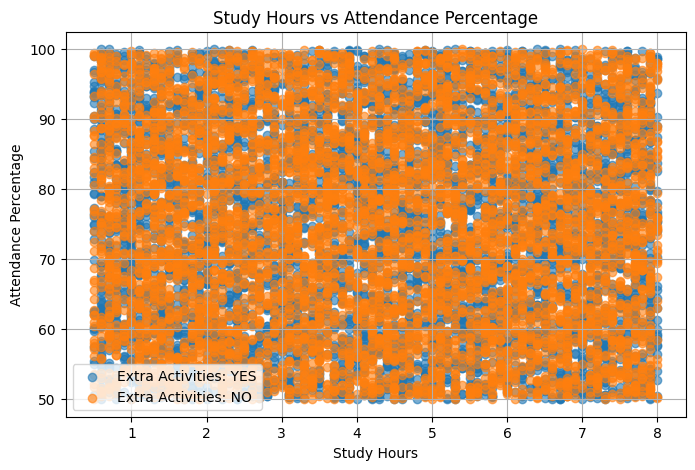

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/Student_Performance.csv')

# Convert Yes/No to numbers
df['extra_activities_num'] = df['extra_activities'].map({
    'yes': 1,
    'no': 0
})

# Scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(
    df[df['extra_activities_num'] == 1]['study_hours'],
    df[df['extra_activities_num'] == 1]['attendance_percentage'],
    label='Extra Activities: YES',
    alpha=0.6
)

plt.scatter(
    df[df['extra_activities_num'] == 0]['study_hours'],
    df[df['extra_activities_num'] == 0]['attendance_percentage'],
    label='Extra Activities: NO',
    alpha=0.6
)

plt.xlabel('Study Hours')
plt.ylabel('Attendance Percentage')
plt.title('Study Hours vs Attendance Percentage')
plt.legend()
plt.grid(True)

plt.show()

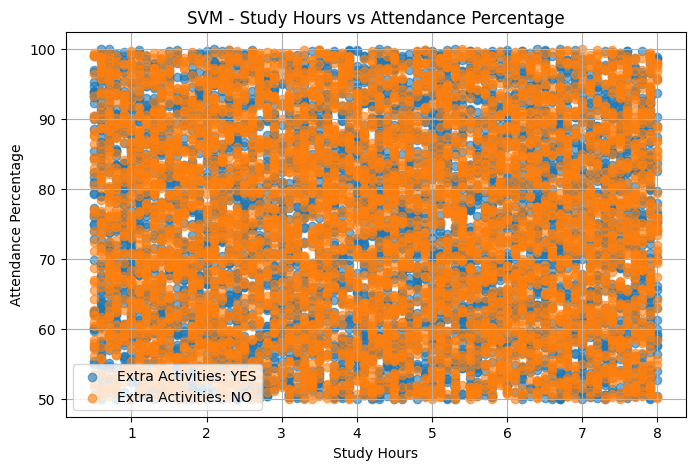

In [26]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(8, 5))

# Extra Activities = YES
plt.scatter(
    data[data['extra_activities'] == 1]['study_hours'],
    data[data['extra_activities'] == 1]['attendance_percentage'],
    label='Extra Activities: YES',
    alpha=0.6
)

# Extra Activities = NO
plt.scatter(
    data[data['extra_activities'] == 0]['study_hours'],
    data[data['extra_activities'] == 0]['attendance_percentage'],
    label='Extra Activities: NO',
    alpha=0.6
)

# Labels and title
plt.xlabel('Study Hours')
plt.ylabel('Attendance Percentage')
plt.title('SVM - Study Hours vs Attendance Percentage')
plt.legend()
plt.grid(True)

# Display graph
plt.show()

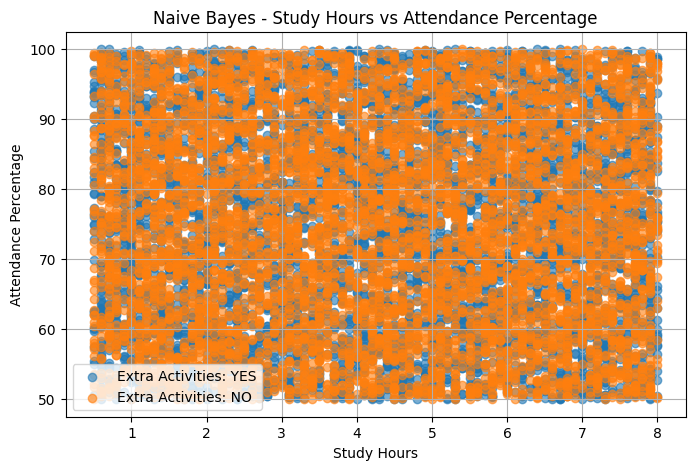

In [27]:
import matplotlib.pyplot as plt

# Scatter plot: Study Hours vs Attendance Percentage

plt.figure(figsize=(8, 5))

# Extra Activities = YES
plt.scatter(
    data[data['extra_activities'] == 1]['study_hours'],
    data[data['extra_activities'] == 1]['attendance_percentage'],
    label='Extra Activities: YES',
    alpha=0.6
)

# Extra Activities = NO
plt.scatter(
    data[data['extra_activities'] == 0]['study_hours'],
    data[data['extra_activities'] == 0]['attendance_percentage'],
    label='Extra Activities: NO',
    alpha=0.6
)

# Labels
plt.xlabel('Study Hours')
plt.ylabel('Attendance Percentage')
plt.title('Naive Bayes - Study Hours vs Attendance Percentage')

# Legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()